# Project FORESIGHT
## Demand Forecasting Model

### Objective

Develop an SKU-level weekly demand forecasting model using LightGBM.

The model will:

- Use historical demand and business features
- Create lag and rolling-demand features
- Use time-based train/test validation
- Evaluate performance using WAPE
- Compare performance against the seasonal-naive baseline
- Save the final model and predictions

In [19]:
import sys
print(sys.executable)

c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\venv\Scripts\python.exe


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from lightgbm import LGBMRegressor
import joblib

In [21]:
ROOT_DIR = Path.cwd().parent

PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(
    PROCESSED_DIR / "analysis_ready_weekly.csv"
)

df["week_start"] = pd.to_datetime(df["week_start"])

df = df.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (18072, 16)


,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,unit_cost,list_price,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-08-12,SKU_0001,15,224659.35,14977.29,0,1,Furniture,Desk,2024-08-12,6911.2,14977.29,53.0,0.0,5.0,17.0
1,2024-08-19,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,27.0,0.0,5.0,17.0
2,2024-08-26,SKU_0001,14,209682.06,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,4.0,37.0,5.0,17.0
3,2024-09-02,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,37.0,0.0,5.0,17.0
4,2024-09-09,SKU_0001,16,239636.64,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,7.0,37.0,5.0,17.0


## Feature Engineering

Lag and rolling features are calculated separately for each SKU.

Only previous observations are used so that future demand does not leak into
the features.

In [22]:
df["month"] = df["week_start"].dt.month
df["quarter"] = df["week_start"].dt.quarter
df["week_of_year"] = (
    df["week_start"]
    .dt.isocalendar()
    .week
    .astype(int)
)

group = df.groupby("sku_id")["units_sold"]

for lag in [1, 2, 4, 8, 12, 52]:
    df[f"lag_{lag}"] = group.shift(lag)

df["rolling_mean_4"] = group.transform(
    lambda x: x.shift(1).rolling(4).mean()
)

df["rolling_mean_8"] = group.transform(
    lambda x: x.shift(1).rolling(8).mean()
)

df["rolling_std_8"] = group.transform(
    lambda x: x.shift(1).rolling(8).std()
)

df.head()

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,...,week_of_year,lag_1,lag_2,lag_4,lag_8,lag_12,lag_52,rolling_mean_4,rolling_mean_8,rolling_std_8
0,2024-08-12,SKU_0001,15,224659.35,14977.29,0,1,Furniture,Desk,2024-08-12,...,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-08-19,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,...,34,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-08-26,SKU_0001,14,209682.06,14977.29,0,0,Furniture,Desk,2024-08-12,...,35,10.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-09-02,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,...,36,14.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-09-09,SKU_0001,16,239636.64,14977.29,0,0,Furniture,Desk,2024-08-12,...,37,10.0,14.0,15.0,NaN,NaN,NaN,12.25,NaN,NaN


In [23]:
# Convert categorical columns only if they exist
for col in ["category", "subcategory"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

In [24]:
feature_columns = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_12",
    "lag_52",
    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_std_8",
    "avg_price",
    "promo_days",
    "holiday_days",
    "on_hand_units",
    "on_order_units",
    "lead_time_days",
    "reorder_point",
    "month",
    "quarter",
    "week_of_year"
]

target = "units_sold"

model_df = df.dropna(
    subset=[
        "lag_1",
        "lag_4",
        "rolling_mean_4"
    ]
).copy()

print("Model dataset shape:", model_df.shape)
print("\nFeatures:")
print(feature_columns)

Model dataset shape: (17272, 28)

Features:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_8', 'avg_price', 'promo_days', 'holiday_days', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'month', 'quarter', 'week_of_year']


## Time-Based Train/Test Split

A random train/test split is not appropriate for forecasting because it can
allow future observations to influence model training.

The final 12 weeks are reserved as the test period.

In [25]:
forecast_horizon = 12

cutoff = (
    model_df["week_start"].max()
    - pd.Timedelta(weeks=forecast_horizon - 1)
)

train = model_df[
    model_df["week_start"] < cutoff
].copy()

test = model_df[
    model_df["week_start"] >= cutoff
].copy()

print(
    "Training:",
    train["week_start"].min(),
    "to",
    train["week_start"].max()
)

print(
    "Testing:",
    test["week_start"].min(),
    "to",
    test["week_start"].max()
)

print("\nTrain rows:", len(train))
print("Test rows:", len(test))

Training: 2023-01-30 00:00:00 to 2025-10-06 00:00:00
Testing: 2025-10-13 00:00:00 to 2025-12-29 00:00:00

Train rows: 14872
Test rows: 2400


In [26]:
X_train = train[feature_columns]
y_train = train[target]

X_test = test[feature_columns]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (14872, 19)
X_test: (2400, 19)


## LightGBM Forecasting Model

LightGBM is used as a tabular forecasting model using historical demand,
lag features, rolling statistics, promotions, holidays, pricing and
inventory information.

In [27]:
model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train,
    y_train
)

print("Model training completed.")

Model training completed.


In [28]:
test["prediction"] = model.predict(X_test)

test["prediction"] = test["prediction"].clip(
    lower=0
)

test[
    ["week_start", "sku_id", "units_sold", "prediction"]
].head()

,week_start,sku_id,units_sold,prediction
61,2025-10-13,SKU_0001,16,21.475205
62,2025-10-20,SKU_0001,22,27.584302
63,2025-10-27,SKU_0001,26,28.126664
64,2025-11-03,SKU_0001,31,24.259666
65,2025-11-10,SKU_0001,26,22.289730


## Evaluation Metric — WAPE

Weighted Absolute Percentage Error (WAPE) is used to evaluate forecasting
accuracy.

Lower WAPE indicates better performance.

In [29]:
def wape(actual, forecast):
    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / denominator
    ) * 100


model_wape = wape(
    test["units_sold"],
    test["prediction"]
)

print(f"LightGBM WAPE: {model_wape:.2f}%")

LightGBM WAPE: 13.44%


In [30]:
baseline = pd.read_csv(
    PROCESSED_DIR / "baseline_predictions.csv"
)

baseline["week_start"] = pd.to_datetime(
    baseline["week_start"]
)

baseline_wape = wape(
    baseline["units_sold"],
    baseline["forecast"]
)

improvement = baseline_wape - model_wape

print(f"Seasonal-Naive WAPE: {baseline_wape:.2f}%")
print(f"LightGBM WAPE:       {model_wape:.2f}%")
print(f"Improvement:         {improvement:.2f} percentage points")

Seasonal-Naive WAPE: 30.34%
LightGBM WAPE:       13.44%
Improvement:         16.90 percentage points


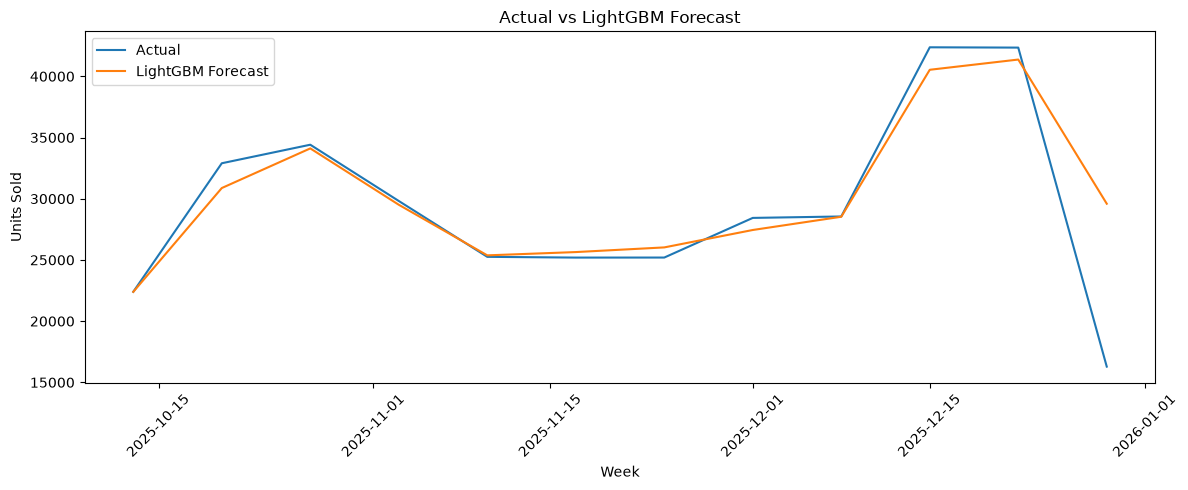

In [31]:
comparison = (
    test
    .groupby("week_start")[["units_sold", "prediction"]]
    .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["units_sold"],
    label="Actual"
)

plt.plot(
    comparison.index,
    comparison["prediction"],
    label="LightGBM Forecast"
)

plt.title("Actual vs LightGBM Forecast")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

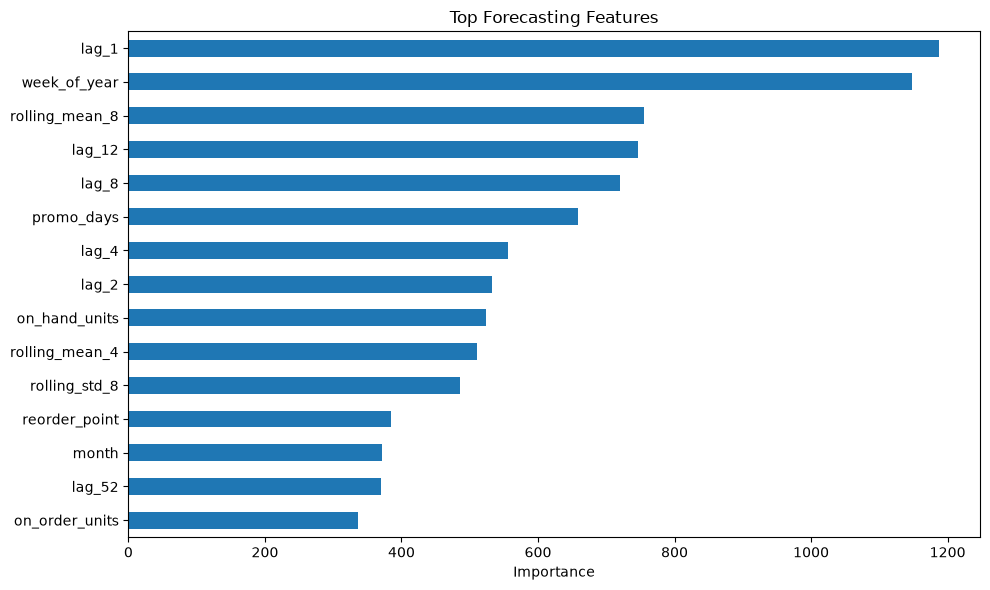

In [32]:
importance = (
    pd.Series(
        model.feature_importances_,
        index=feature_columns
    )
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Top Forecasting Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
prediction_path = (
    PROCESSED_DIR
    / "forecast_predictions.csv"
)

test[
    [
        "week_start",
        "sku_id",
        "units_sold",
        "prediction"
    ]
].to_csv(
    prediction_path,
    index=False
)

print("Predictions saved to:", prediction_path)

Predictions saved to: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\data\processed\forecast_predictions.csv


In [34]:
model_path = (
    MODELS_DIR
    / "lightgbm_forecast_model.pkl"
)

joblib.dump(
    model,
    model_path
)

print("Model saved to:", model_path)

Model saved to: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\models\lightgbm_forecast_model.pkl


# Forecasting Results

The LightGBM model was evaluated on a chronological 12-week holdout period
using WAPE.

Its performance was compared against the seasonal-naive baseline.

The resulting forecasts will be used in the inventory risk scoring and
recommendation stage.